# 事前課題 — 環境確認 ＋ PyTorch 基礎の手触り

このノートブックは環境構築の確認と，第1回に向けた予習を兼ねている．

**やること**：
1. 環境チェック — torch / torchaudio のバージョンと SPEECHCOMMANDS データの有無を確認
2. Tensors — shape / dtype / device / squeeze / unsqueeze を手で触る
3. Datasets & DataLoaders — PyTorch のデータ読み込みの仕組みを体験する

上から順にセルを実行していく．エラーが出たら `session0_prep.md` の「詰まったときは」を参照．

In [1]:
import os
from pathlib import Path
if Path.cwd().name == "notebooks":
    os.chdir("..")
print("cwd:", Path.cwd())

cwd: /home/ymgt/ShiotaLab/B4_rinko_torchaudio


## 1. 環境チェック

`scripts/smoke.py` と同じ内容をここで実行する．
`torch` / `torchaudio` の version が表示され，`SPEECHCOMMANDS: found` と出れば環境は完成．

In [2]:
import torch
import torchaudio

print("torch       :", torch.__version__)
print("torchaudio  :", torchaudio.__version__)
print("CUDA avail  :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device      :", torch.cuda.get_device_name(0))

sc_dir = Path("data") / "SpeechCommands" / "speech_commands_v0.02"
if sc_dir.exists():
    print("SPEECHCOMMANDS: found  ->", sc_dir)
else:
    print("SPEECHCOMMANDS: NOT found. 手順5のデータ取得をまだ実行していません．")

torch       : 2.4.1+cu121
torchaudio  : 2.4.1+cu121
CUDA avail  : True
device      : NVIDIA GeForce RTX 3090
SPEECHCOMMANDS: found  -> data/SpeechCommands/speech_commands_v0.02


## 2. Tensors

PyTorch 公式チュートリアル "Tensors" 章の内容を手で触って確認する．
予習で読んだ問いと照らしながら実行してみよう．

### テンソルを作る・形を見る

In [3]:
# torch.tensor で直接作る
a = torch.tensor([1, 2, 3])
print("a:", a)

# torch.zeros / torch.randn で作る
b = torch.zeros(2, 3)
c = torch.randn(2, 3)
print("b (zeros):", b)
print("c (randn):", c)

# shape を確認する
print("a.shape:", a.shape)
print("b.shape:", b.shape)

a: tensor([1, 2, 3])
b (zeros): tensor([[0., 0., 0.],
        [0., 0., 0.]])
c (randn): tensor([[ 1.8544, -1.4014, -0.4937],
        [ 0.0378,  0.8488, -0.2980]])
a.shape: torch.Size([3])
b.shape: torch.Size([2, 3])


### dtype — データ型

テンソルの要素はすべて同じ型．整数リストから作ると `int64`，小数から作ると `float32` になる．
モデルの重みや特徴量は `float32`，ラベルは `int64`（`long`）で扱うのが PyTorch の慣例．

In [4]:
int_tensor = torch.tensor([1, 2, 3])
float_tensor = torch.tensor([1.0, 2.0, 3.0])
print("int:", int_tensor.dtype)     # torch.int64
print("float:", float_tensor.dtype) # torch.float32

# torch.long は torch.int64 の別名
print("long == int64:", torch.long == torch.int64)

int: torch.int64
float: torch.float32
long == int64: True


### device — テンソルの居場所

テンソルは CPU か GPU のどちらかに存在する．
`.to(device)` で移動できるが，演算する2つのテンソルは同じ device にないとエラーになる．

In [5]:
dev = "cuda" if torch.cuda.is_available() else "cpu"
print("使う device:", dev)

x = torch.randn(3, 3)
print("作った直後:", x.device)

x_dev = x.to(dev)
print("移動後:", x_dev.device)

使う device: cuda
作った直後: cpu
移動後: cuda:0


### squeeze / unsqueeze — サイズ1の次元を消す / 足す

torchaudio が返す波形は `(1, T)` の shape（チャネル次元あり）．
- `squeeze(0)`: サイズ1の次元を消す → `(T,)`
- `unsqueeze(0)`: サイズ1の次元を足す → `(1, T)`

第1回で `waveform.squeeze(0)` や `unsqueeze(1)` を使う場面がある．

In [6]:
# torchaudio の waveform を想定：(1, T)
waveform = torch.randn(1, 16000)
print("元:", waveform.shape)

# squeeze(0) でチャネル次元を消す
w1d = waveform.squeeze(0)
print("squeeze(0):", w1d.shape)

# unsqueeze(0) で次元を足す
w2d = w1d.unsqueeze(0)
print("unsqueeze(0):", w2d.shape)

# unsqueeze(1) で別の位置に足す
batch = torch.randn(8, 64, 101)
print("\nbatch:", batch.shape)
print("unsqueeze(1):", batch.unsqueeze(1).shape)  # (8, 1, 64, 101)

元: torch.Size([1, 16000])
squeeze(0): torch.Size([16000])
unsqueeze(0): torch.Size([1, 16000])

batch: torch.Size([8, 64, 101])
unsqueeze(1): torch.Size([8, 1, 64, 101])


## 3. Datasets & DataLoaders

PyTorch 公式チュートリアル "Datasets & DataLoaders" 章の内容を体験する．

- **Dataset**: 1件のデータを取り出す役割
- **DataLoader**: Dataset から複数件を束ねてバッチにする役割

### Dataset を触る — SPEECHCOMMANDS

`torchaudio.datasets.SPEECHCOMMANDS` は PyTorch の `Dataset` を継承したクラス．
`ds[i]` で i 番目のサンプルを取り出せる．

In [7]:
import torchaudio

ds = torchaudio.datasets.SPEECHCOMMANDS(root="data", download=False, subset="training")
print("サンプル数:", len(ds))

# 1件取り出す
waveform, sr, label, speaker_id, utterance_number = ds[0]
print("waveform:", waveform.shape, "| sr:", sr, "| label:", label)

サンプル数: 84843
waveform: torch.Size([1, 16000]) | sr: 16000 | label: backward


### DataLoader を触る

`DataLoader` は `Dataset` をラップして，バッチ単位でイテレーションできるようにする．
`batch_size` で何件ずつ束ねるか，`shuffle` でランダムに取り出すかを指定する．

In [8]:
from torch.utils.data import DataLoader

# まずは簡単な例：整数のリストを Dataset として使う
simple_data = list(range(10))
loader = DataLoader(simple_data, batch_size=3, shuffle=False)

for batch in loader:
    print(batch)

tensor([0, 1, 2])
tensor([3, 4, 5])
tensor([6, 7, 8])
tensor([9])


### collate_fn — バッチのまとめ方をカスタムする

`DataLoader` はデフォルトで `torch.stack` でバッチにまとめるが，
サンプルごとにサイズが違うとそのままでは stack できない．
SPEECHCOMMANDS の音声は長さがバラバラなので，揃える処理が必要になる．

これが `collate_fn` の出番．第1回で実際に書く．

In [9]:
# 長さがバラバラなテンソルを stack しようとすると…
try:
    torch.stack([torch.zeros(3), torch.zeros(5)])
except RuntimeError as e:
    print("エラー:", e)

# 長さを揃えれば stack できる
a = torch.zeros(5)
b = torch.zeros(5)
print("揃えれば OK:", torch.stack([a, b]).shape)

エラー: stack expects each tensor to be equal size, but got [3] at entry 0 and [5] at entry 1
揃えれば OK: torch.Size([2, 5])


### SPEECHCOMMANDS を覗く

第1回で使うデータを先に覗いておく．波形と log-mel スペクトログラムを可視化する．

/home/ymgt/ShiotaLab/B4_rinko_torchaudio/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


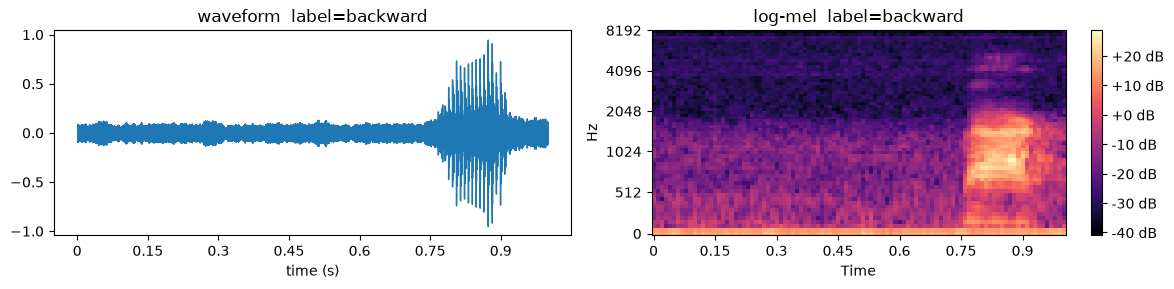

In [10]:
import matplotlib.pyplot as plt
import librosa
import librosa.display
import numpy as np

waveform, sr, label, *_ = ds[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# 波形
librosa.display.waveshow(waveform.squeeze(0).numpy(), sr=sr, ax=axes[0])
axes[0].set_title(f"waveform  label={label}")
axes[0].set_xlabel("time (s)")

# log-mel スペクトログラム
import torchaudio.transforms as T
from torch import nn

logmel = nn.Sequential(
    T.MelSpectrogram(sample_rate=sr, n_fft=400, hop_length=160, n_mels=64),
    T.AmplitudeToDB(),
)
spec = logmel(waveform)

librosa.display.specshow(
    spec.squeeze(0).numpy(), sr=sr, hop_length=160,
    x_axis="time", y_axis="mel", ax=axes[1], cmap="magma"
)
axes[1].set_title(f"log-mel  label={label}")
plt.colorbar(axes[1].collections[0], ax=axes[1], format="%+2.0f dB")

fig.tight_layout()
plt.show()

## まとめ

- 環境チェックが通れば事前準備は完了
- Tensors: shape / dtype / device / squeeze / unsqueeze の感覚を掴んだ
- Dataset は1件取り出す役割，DataLoader はバッチに束ねる役割
- 長さが違うデータをバッチにするには `collate_fn` が必要 → 第1回で書く

### 次のステップ

予習の問いに自分の言葉で答えをまとめて，第1回に持ってくる．